In [45]:
import os
from pathlib import Path
os.chdir(Path.cwd())


In [46]:
import re
from pathlib import Path
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns

In [47]:
project_dir = Path.cwd().parent
print(project_dir)
data_dir = project_dir / "data/processed"

k:\PythonWork\downscaling\Kaya_downscaling


In [48]:
df_city_emissions = pd.DataFrame()
profiles = ["base_run",  "sensitivity_3", "sensitivity_4", "sensitivity_5", "sensitivity_6"]

for profile in profiles:
    data_dir_profile = data_dir / profile
    print(data_dir_profile)
    dirs_profile = [p for p in data_dir_profile.rglob("*") if p.is_dir()]

    for d in dirs_profile:
        # skip "_gross"
        if d.name.endswith("_gross"):
            continue
        file = next(d.glob("emissions_per_city_*"), None)
        if file is not None and (d.name.startswith("IMAGE") or d.name.startswith("REMIND")):
            print(f"Directory: {d.name}")
            print(f"File: {file}")
            add = pd.read_csv(file, sep=";")
            add["profile"] = profile
            add["model"] = d.name.split("_")[0]
            m = re.search(r"((?:Low|Medium).*?)_conv_year", d.name, flags=re.IGNORECASE)
            scenario = m.group(1) if m else None
            add["scenario"] = scenario
            m = re.search(r"_conv_year_(\d+)", d.name)
            conv_year = int(m.group(1)) if m else None
            print(f"Convergence year: {conv_year}")
            add["convergence_year"] = conv_year

            df_city_emissions = pd.concat([df_city_emissions, add], ignore_index=True)
df_city_emissions.to_csv(project_dir / "data"/ "check" / "emissions_per_city_all.csv", sep=";", index=False)

print(f"\nChecks:")
print(df_city_emissions.dtypes)
print(df_city_emissions["variable"].unique())
print(df_city_emissions["model"].unique())
print(df_city_emissions["scenario"].unique())
print(df_city_emissions["convergence_year"].unique())
df_city_emissions[df_city_emissions["variable"]=="sum_weighted"]


k:\PythonWork\downscaling\Kaya_downscaling\data\processed\base_run
Directory: IMAGE_ScenarioMIP_IMAGE 3.4_Low - SSP1_conv_year_2150_net
File: k:\PythonWork\downscaling\Kaya_downscaling\data\processed\base_run\IMAGE_ScenarioMIP_IMAGE 3.4_Low - SSP1_conv_year_2150_net\emissions_per_city_IMAGE 3.4_Low - SSP1_Emissions_CO2_Excl_shipping_aviation_AFOLU.csv
Convergence year: 2150
Directory: IMAGE_ScenarioMIP_IMAGE 3.4_Low - SSP2_conv_year_2120_net
File: k:\PythonWork\downscaling\Kaya_downscaling\data\processed\base_run\IMAGE_ScenarioMIP_IMAGE 3.4_Low - SSP2_conv_year_2120_net\emissions_per_city_IMAGE 3.4_Low - SSP2_Emissions_CO2_Excl_shipping_aviation_AFOLU.csv
Convergence year: 2120
Directory: IMAGE_ScenarioMIP_IMAGE 3.4_Low - SSP2_conv_year_2150_net
File: k:\PythonWork\downscaling\Kaya_downscaling\data\processed\base_run\IMAGE_ScenarioMIP_IMAGE 3.4_Low - SSP2_conv_year_2150_net\emissions_per_city_IMAGE 3.4_Low - SSP2_Emissions_CO2_Excl_shipping_aviation_AFOLU.csv
Convergence year: 2150
Dir

,city,year,scenario,variable,value,profile,model,convergence_year
0,Amsterdam,2020,Low - SSP1,sum_weighted,10.892563,base_run,IMAGE,2150
1,Amsterdam,2030,Low - SSP1,sum_weighted,8.597712,base_run,IMAGE,2150
2,Amsterdam,2040,Low - SSP1,sum_weighted,4.048643,base_run,IMAGE,2150
3,Amsterdam,2050,Low - SSP1,sum_weighted,2.075483,base_run,IMAGE,2150
4,Lima,2020,Low - SSP1,sum_weighted,8.998748,base_run,IMAGE,2150
...,...,...,...,...,...,...,...,...
1547,Raleigh,2050,Medium - SSP2,sum_weighted,0.863388,sensitivity_5,IMAGE,2150
1548,New York,2020,Medium - SSP2,sum_weighted,23.096673,sensitivity_5,IMAGE,2150
1549,New York,2030,Medium - SSP2,sum_weighted,26.127418,sensitivity_5,IMAGE,2150
1550,New York,2040,Medium - SSP2,sum_weighted,19.172768,sensitivity_5,IMAGE,2150


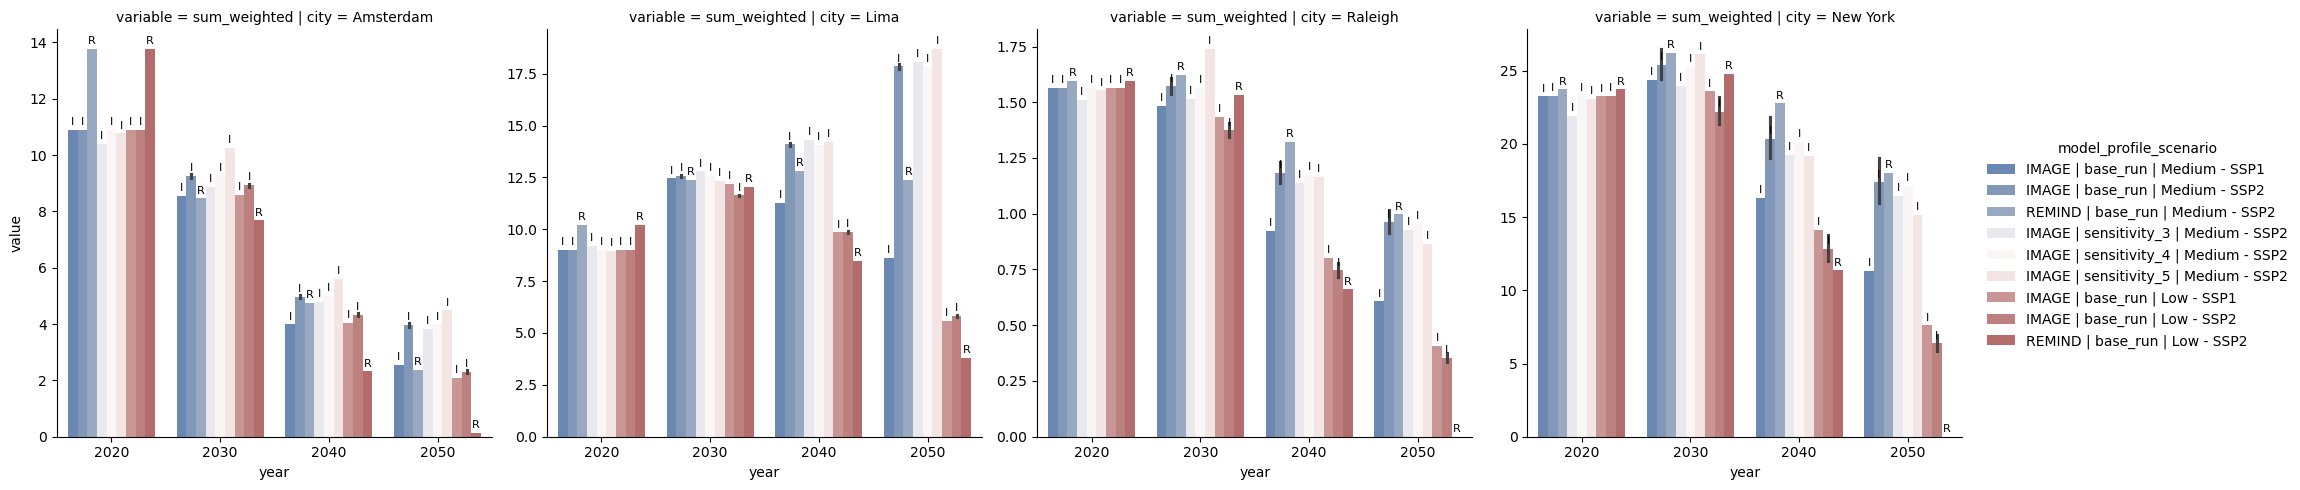

In [49]:
df_city_emmisions_total_em = df_city_emissions[df_city_emissions["variable"] == "sum_weighted"].assign(
    model_profile_scenario=lambda g: g["model"] + " | " + g["profile"] + " | " + g["scenario"])
letter = {"IMAGE": "I", "REMIND": "R"}
tier = lambda s: 0 if "Medium" in s else 1  # Medium first, then Low

hue_order = sorted(df_city_emmisions_total_em["model_profile_scenario"].unique(),
                   key=lambda s: (tier(s), s.split(" | ")[2], s.split(" | ")[1], s.split(" | ")[0]))

cmap = sns.color_palette("vlag", as_cmap=True)
# e.g. 5 colors evenly spaced, same as color_palette("vlag", 5):
colors = [cmap(x) for x in np.linspace(0, 1, 5)]
n_groups = int(np.ceil(len(hue_order) / 3))
palette = {}
for gi in range(n_groups):
    center = (gi + 0.5) / n_groups
    shades = [cmap(center - 0.06), cmap(center), cmap(center + 0.06)]  # tweak 0.06 for spread
    for j in range(3):
        idx = gi * 3 + j
        if idx < len(hue_order):
            palette[hue_order[idx]] = shades[j]

g = sns.catplot(data=df_city_emmisions_total_em, x="year", y="value", hue="model_profile_scenario",
                hue_order=hue_order, palette=palette, row="variable", col="city", kind="bar", sharey=False)

for ax in g.axes.flat:
    for cont, hl in zip(ax.containers, hue_order):
        lab = letter.get(hl.split(" | ")[0], "")
        ax.bar_label(cont, labels=[lab] * len(cont.patches), padding=2, fontsize=8)

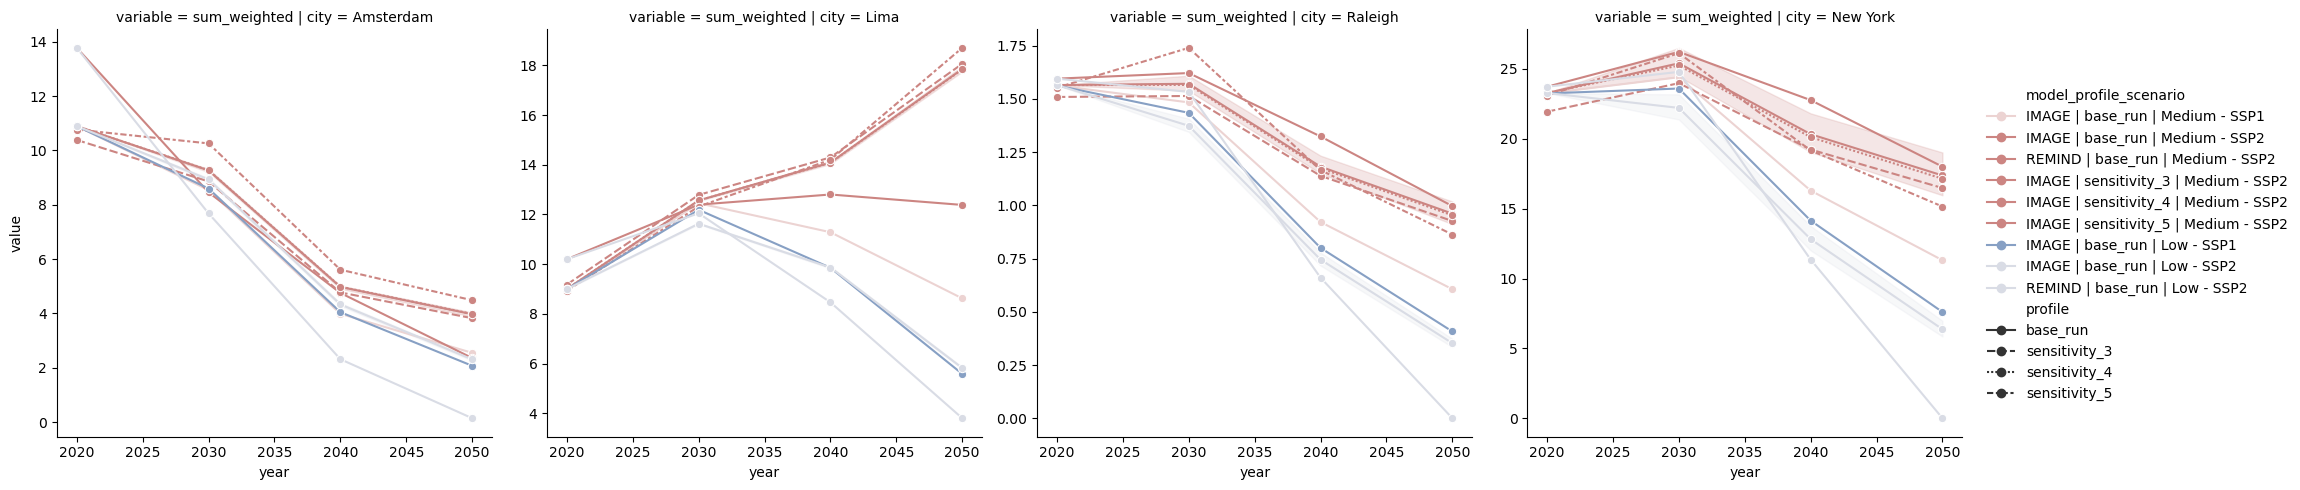

In [50]:
scenarios = sorted(df_city_emmisions_total_em["scenario"].unique())
scen_color = dict(zip(scenarios, sns.color_palette("vlag", len(scenarios))))
palette = {hl: scen_color[hl.split(" | ")[2]] for hl in hue_order}

g = sns.relplot(data=df_city_emmisions_total_em, x="year", y="value",
                hue="model_profile_scenario", hue_order=hue_order, palette=palette,
                style="profile", row="variable", col="city", kind="line",
                marker="o", facet_kws={"sharey": False})

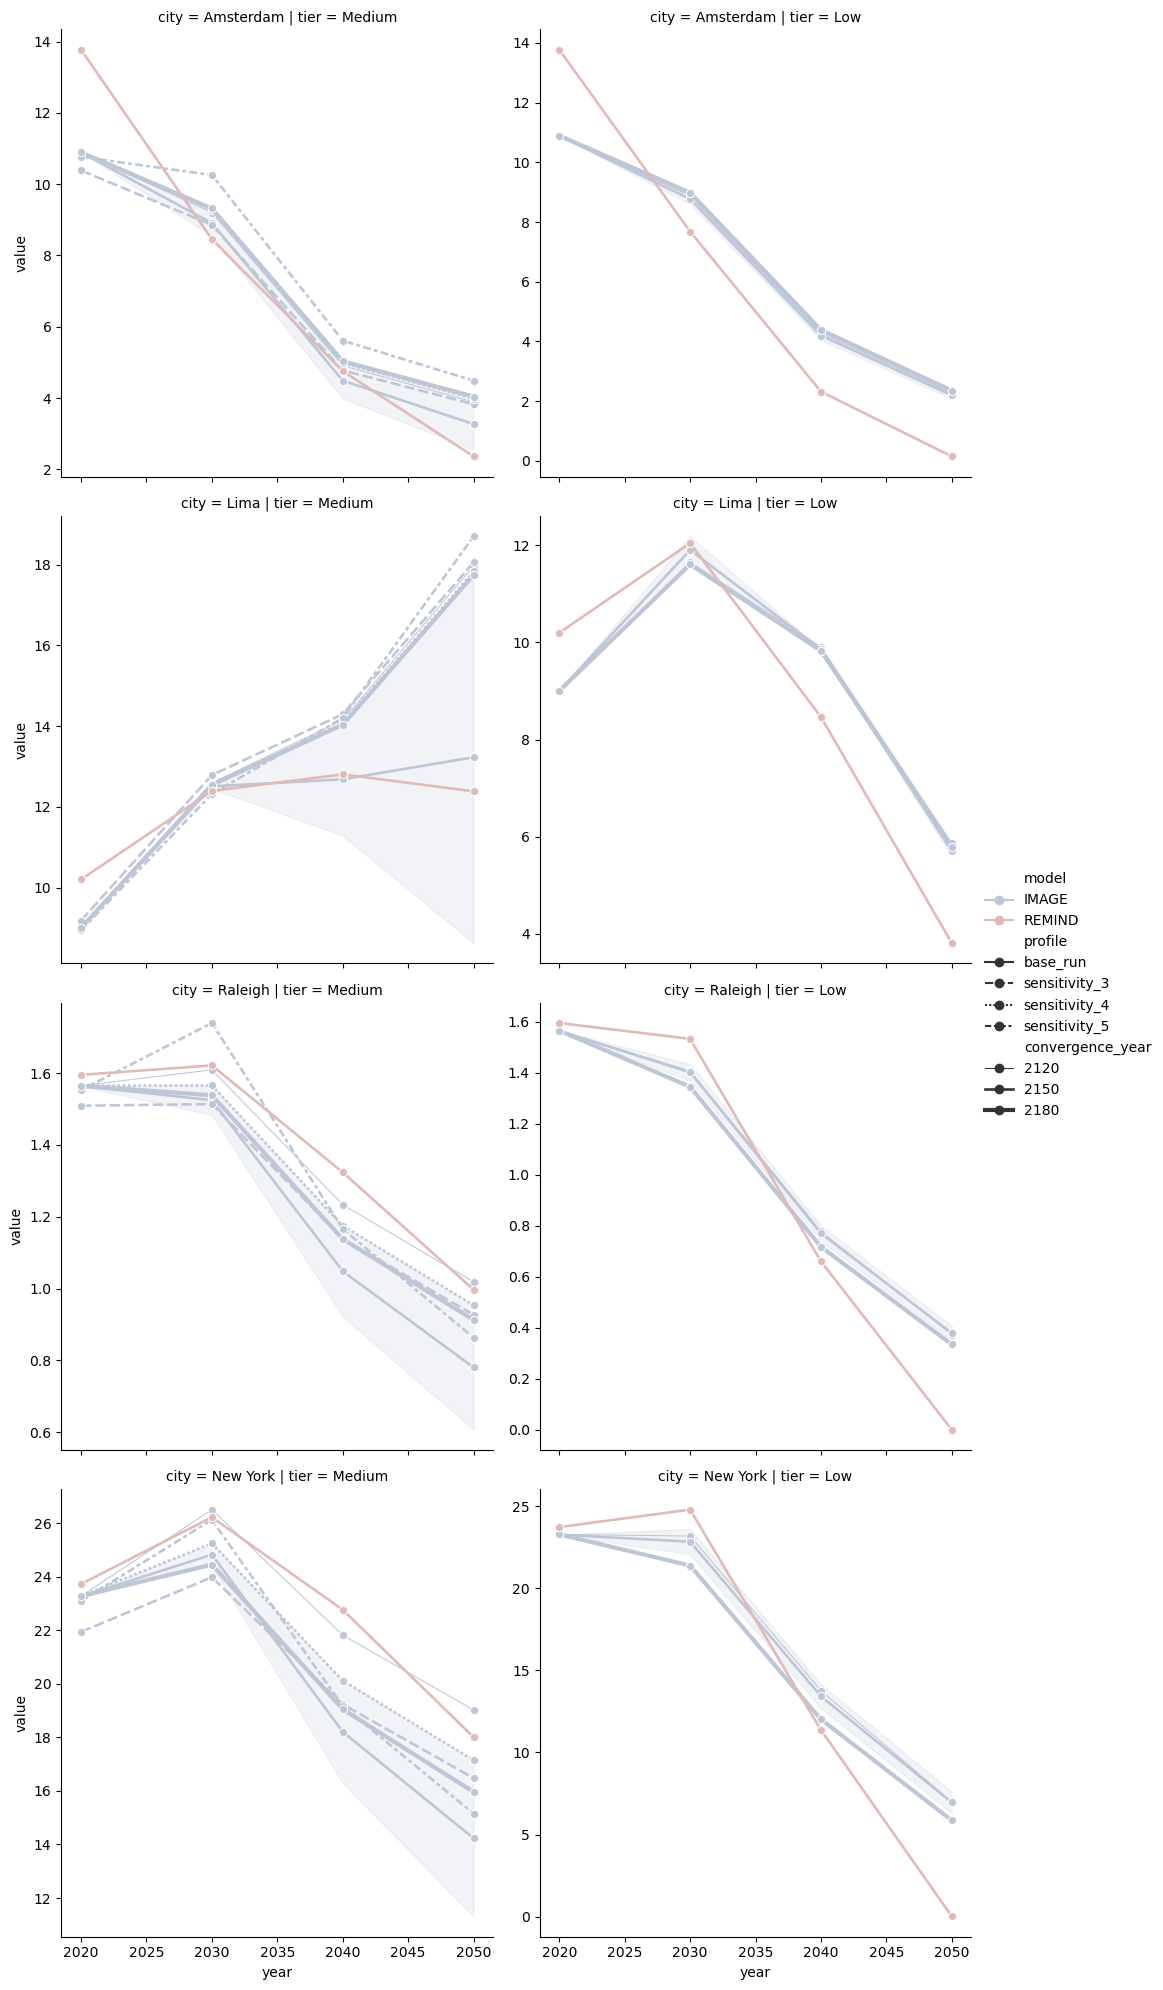

In [51]:
df_city_emmisions_total_em = df_city_emmisions_total_em.assign(
    tier=lambda g: np.where(g["scenario"].str.contains("Medium"), "Medium", "Low"))

tier = lambda s: 0 if "Medium" in s else 1
hue_order_scen = sorted(df_city_emmisions_total_em["scenario"].unique(), key=lambda s: (tier(s), s))

g = sns.relplot(data=df_city_emmisions_total_em, x="year", y="value",
                hue="model", style="profile", size="convergence_year", palette="vlag",
                row="city", col="tier", col_order=["Medium", "Low"], kind="line",
                marker="o", facet_kws={"sharey": False})

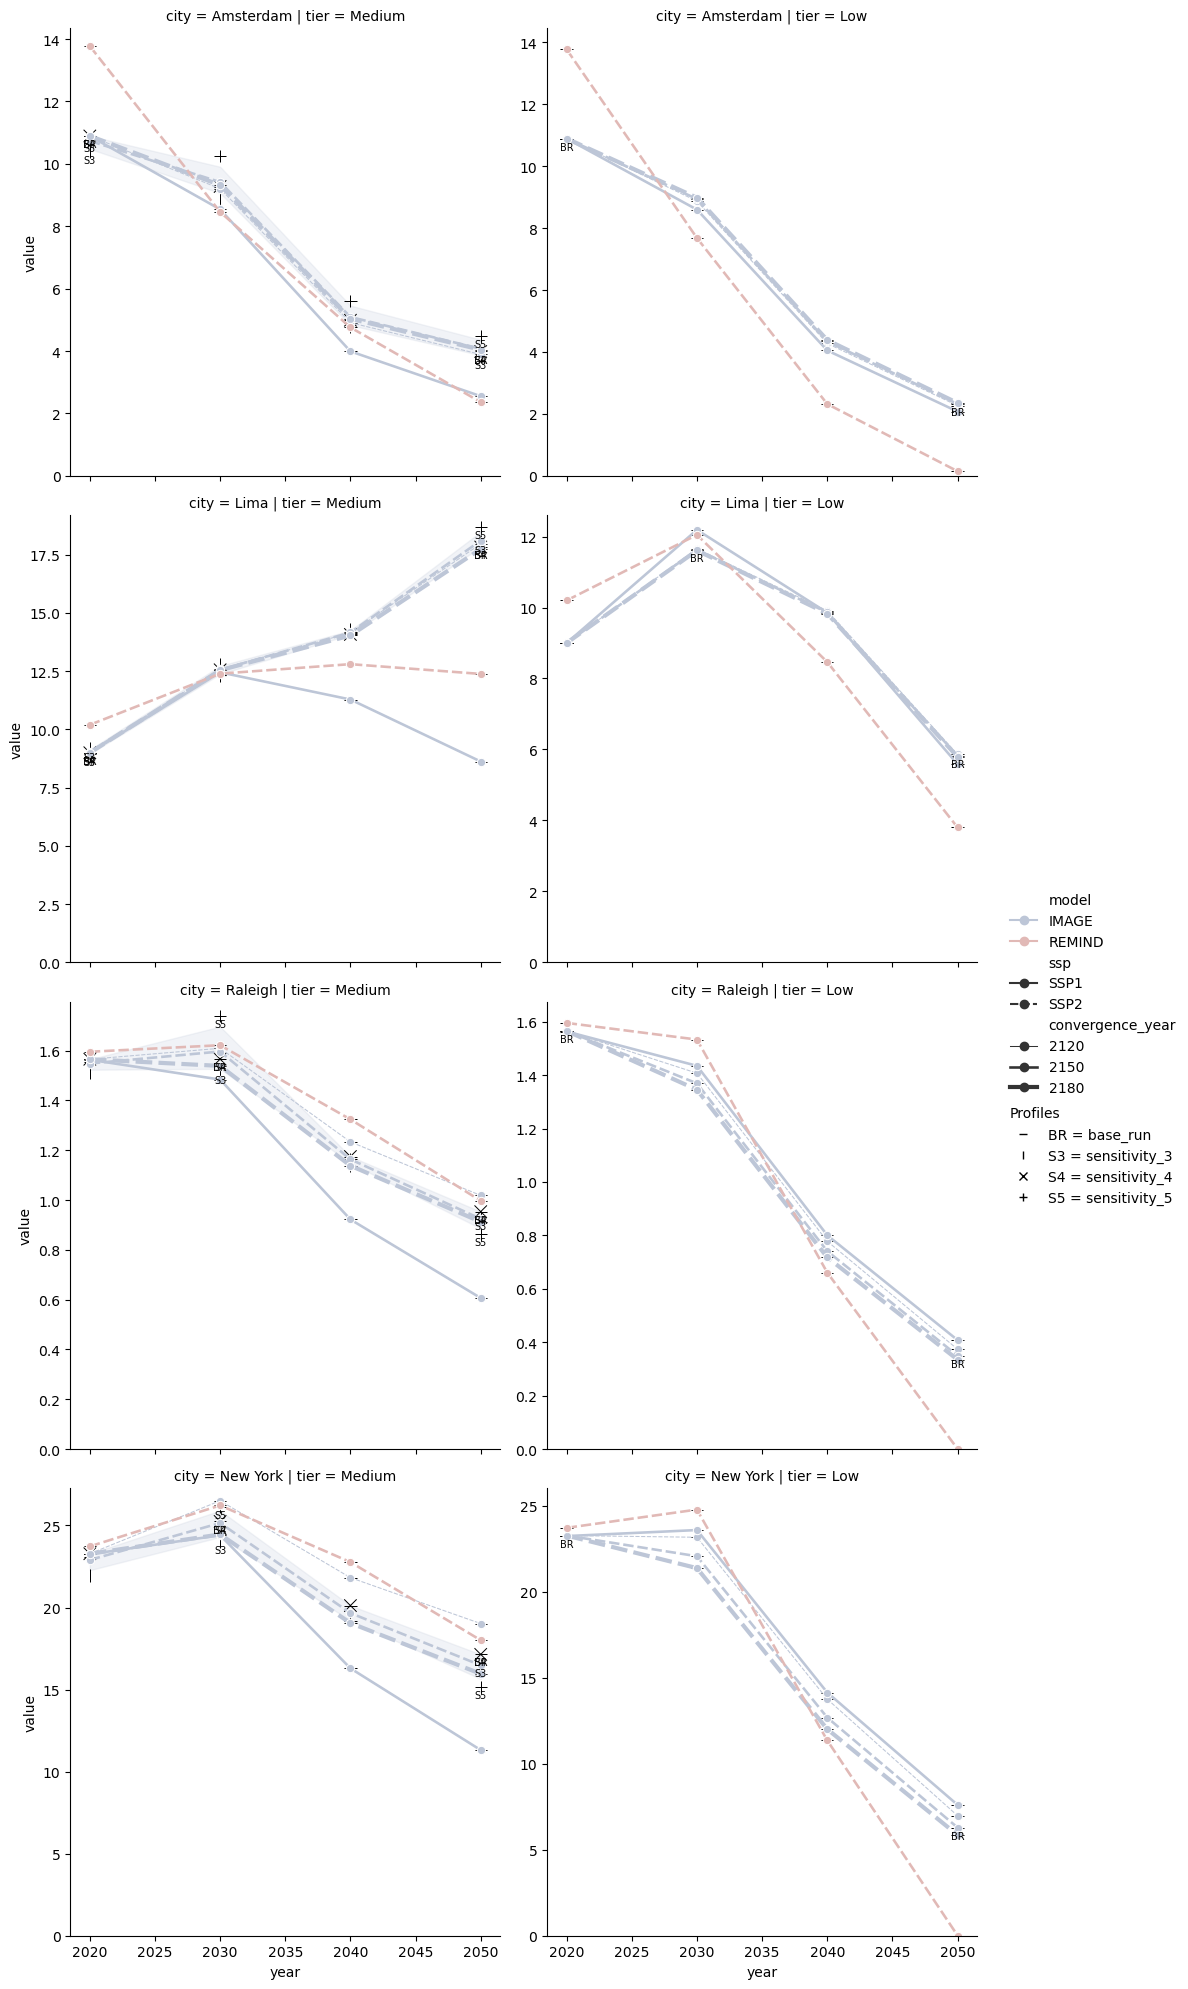

In [54]:
df_city_emmisions_total_em = df_city_emmisions_total_em.assign(
    tier=lambda g: np.where(g["scenario"].str.contains("Medium"), "Medium", "Low"),
    ssp=lambda g: g["scenario"].str.extract(r"(SSP\d)", expand=False))

prof_abbrev = {"base_run": "BR", "sensitivity_3": "S3", "sensitivity_4": "S4", "sensitivity_5": "S5"}
profiles = sorted(df_city_emmisions_total_em["profile"].unique())
prof_markers = dict(zip(profiles, ["_", "|", "x", "+", "o", "s"]))
line_keys = ["model", "ssp", "profile", "convergence_year"]

def annotate_extremes(data, **kwargs):
    ax = plt.gca()
    for keys, line in data.groupby(line_keys):
        k = dict(zip(line_keys, keys))
        if not (k["model"] == "IMAGE" and k["ssp"] == "SSP2" and k["convergence_year"] == 2150):
            continue
        ab = prof_abbrev.get(k["profile"], k["profile"])
        for pt in (line.loc[line["value"].idxmin()], line.loc[line["value"].idxmax()]):
            ax.annotate(ab, (pt["year"], pt["value"]), textcoords="offset points",
                        xytext=(0, -8), ha="center", fontsize=7)

g = sns.relplot(data=df_city_emmisions_total_em, x="year", y="value",
                hue="model", style="ssp", size="convergence_year", palette="vlag",
                row="city", col="tier", col_order=["Medium", "Low"], kind="line",
                marker="o", facet_kws={"sharey": False})

g.map_dataframe(sns.scatterplot, x="year", y="value", style="profile",
                markers=prof_markers, color="black", s=80, legend=False)
g.map_dataframe(annotate_extremes)

for ax in g.axes.flat:
    ax.set_ylim(bottom=0)

# match the profile legend font to seaborn's legend
from matplotlib.lines import Line2D
from matplotlib.font_manager import FontProperties

leg_text = g.legend.get_texts()[0]
fp = FontProperties(family=leg_text.get_fontfamily(), size=leg_text.get_fontsize())

handles = [Line2D([0], [0], marker=prof_markers.get(name, "_"), color="black", linestyle="",
                  label=f"{ab} = {name}") for name, ab in prof_abbrev.items()]

prof_legend = g.fig.legend(handles=handles, bbox_to_anchor=(x_left, 0.45),
                           loc="upper left", title="Profiles", prop=fp,
                           frameon=False, alignment="left")
prof_legend._legend_box.align = "left"